# Dolomite surface titration in NaCl — Pokrovsky (1999), solved step by step

This notebook follows **Pokrovsky et al. (1999)**. The net surface charge is the charge-sum
difference of Charlet et al. (1990), their **Eqn 1**:

$$\sigma_T=\frac{1}{S}\left(\sum_k z_k[k]_0-\sum_k z_k[k]_f\right)$$

* $[k]_0$ — the conservative **closed** 1:1 mix of reactors A and B (the zero-charge reference, the
  proton condition of reactor A),
* $[k]_f$ — the **actual** reactor C, computed from the **measured pH**, alkalinity and total Ca/Mg,
* $S$ — the dolomite surface area per litre of reactor C, $z_k$ the charge of species $k$.

No surface complexation model is fitted. Speciation uses **Davies activity coefficients** and the
**Plummer–Busenberg / Nordstrom** formation constants, exactly as in the paper. The solution is built
one step at a time: activity coefficients → mass action (with the γ substitution) → free ions from the
mass balances → charge balance → surface charge.

**Two things this notebook is explicit about.** (1) Pokrovsky uses the **measured** pH; it is the
observable that encodes the surface reaction, so it is used directly. (2) The carbonate model is a
switch: `'closed'` uses the measured alkalinity (the paper's choice, and what keeps carbonate bounded
at high pH); `'open'` fixes pCO₂. Open atmospheric pCO₂ predicts hundreds of mM of carbonate above
pH 9 and breaks the base runs, so `'closed'` is the default — flip it to see the difference.

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Constants and thermodynamic data

Formation constants (25 °C), Plummer–Busenberg (1982) and Nordstrom et al. (1990). `logKH` sets
CO₂(aq) from pCO₂ by Henry's law; `pCO2_atm` is the open-system value.

In [2]:
A_DAVIES = 0.509           # Davies equation constant
KW       = 1.0e-14          # water dissociation, [H+][OH-]
logKH    = -1.47            # CO2(g) = CO2(aq):  [CO2(aq)] = 10**logKH * pCO2
pCO2_atm = 10**-3.5         # atmospheric CO2 partial pressure (atm)

# formation constants  (log10 K), complex on the RIGHT of the reaction
logK = dict(
    Ka2    = -10.329,   # HCO3-          = H+ + CO3^2-      (written as dissociation)
    Kco2   =  -6.35,    # CO2(aq) + H2O  = H+ + HCO3-
    CaCO3  =   3.224,   # Ca2+ + CO3^2-  = CaCO3(aq)
    CaHCO3 =   1.106,   # Ca2+ + HCO3-   = CaHCO3+
    CaOH   = -12.78,    # Ca2+ + H2O     = CaOH+ + H+
    MgCO3  =   2.98,    # Mg2+ + CO3^2-  = MgCO3(aq)
    MgHCO3 =   1.07,    # Mg2+ + HCO3-   = MgHCO3+
    MgOH   = -11.44,    # Mg2+ + H2O     = MgOH+ + H+
    NaCO3  =   1.27,    # Na+  + CO3^2-  = NaCO3-
    NaHCO3 =  -0.25,    # Na+  + HCO3-   = NaHCO3(aq)
)

# molar masses (g/mol)
MM = dict(Ca=40.078, Mg=24.305, CO3=60.008, HCO3=61.016, Na=22.99, Cl=35.45)

# surface area of dolomite per litre of reactor C  (S in Eqn 1)
SSA_m2_g   = 0.84          # specific surface area, m2/g
loading_gL = 30.0          # 6 g of solid in 0.2 L of reactor C
St         = SSA_m2_g * loading_gL      # = 25.2 m2 / L

# carbonate model:  'closed' = measured alkalinity (Pokrovsky) ; 'open' = fixed pCO2
CARBONATE = 'closed'

SITE_CEILING = 0.0166      # site-density ceiling, mmol/m2 (~10 sites/nm2)

## 2. Step 1 — activity coefficients (Davies)

Every mass-action law is written in **activities** $\{i\}=\gamma_i[i]$. The Davies equation gives the
activity coefficient from the ionic strength $I$, one value per charge:

$$\log\gamma_z=-A\,z^2\left(\frac{\sqrt I}{1+\sqrt I}-0.3\,I\right)$$

`gammas(I)` returns $\gamma_1$ (for $z=1$) and $\gamma_2$ (for $z=2$).

In [3]:
def gammas(I):
    if I <= 0:
        return 1.0, 1.0
    f = -A_DAVIES * (np.sqrt(I)/(1.0 + np.sqrt(I)) - 0.3*I)
    return 10**f, 10**(4*f)      # z^2 = 1 (monovalent), z^2 = 4 (divalent)

## 3. Step 2 — law of mass action, with the γ substitution

Work in activities, then divide by the activity coefficient to get a concentration. `aH = 10**(-pH)`
is the proton activity (pH is the **measured** value).

**Carbonate ladder.** Two ways to set it, chosen by `CARBONATE`:

* `'open'` — CO₂(aq) is fixed by Henry's law and the rest follow from pH:

$$\{CO_2\}=10^{logKH}\,p_{CO_2},\quad
\{HCO_3^-\}=\frac{10^{Kco2}\{CO_2\}}{\{H^+\}},\quad
\{CO_3^{2-}\}=\frac{10^{Ka2}\{HCO_3^-\}}{\{H^+\}}$$

* `'closed'` — the free carbonate `cCO3` is the unknown, scaled so the total inorganic carbon equals the
  measured DIC (see step 3).

Concentrations come from the activities: $[HCO_3^-]=\{HCO_3^-\}/\gamma_1$, $[CO_3^{2-}]=\{CO_3^{2-}\}/\gamma_2$.

**Complexes.** Each formation law in activities, then substituted to concentrations, e.g.

$$\{CaCO_3\}=10^{K_{CaCO3}}\{Ca^{2+}\}\{CO_3^{2-}\}
\;\Rightarrow\;[CaCO_3]=10^{K_{CaCO3}}\,\gamma_2^2\,[Ca^{2+}][CO_3^{2-}]$$

(CaCO₃ is neutral so γ≈1 on the left; the two γ₂ come from {Ca²⁺} and {CO₃²⁻}). The other complexes
follow the same pattern and are assembled inside `speciate` below.

## 4. Step 3 — free ions from the mass balances, iterated with I

For a given pH the free metals are found from their **mass-balance denominators**. Collecting every
Ca species,

$$Ca_T=[Ca^{2+}]\Big(1+10^{K_{CaCO3}}\gamma_2^2[CO_3]+10^{K_{CaHCO3}}\gamma_2[HCO_3]
+10^{K_{CaOH}}\tfrac{\gamma_2}{\{H^+\}\gamma_1}\Big)=[Ca^{2+}]\,d_{Ca}$$

so $[Ca^{2+}]=Ca_T/d_{Ca}$, and likewise for Mg and Na. Ionic strength depends on the very
concentrations we are solving for, so the whole thing is iterated: guess $I$ → γ → carbonate → free
ions → complexes → new $I$, until $I$ stops changing. In `'closed'` mode an inner loop scales `cCO3`
until the total inorganic carbon matches the measured DIC.

In [4]:
def speciate(pH, Ca_T, Mg_T, Na_T, Cl_T, DIC=None, itmax=300, tol=1e-13):
    """Speciation at the MEASURED pH. CARBONATE='open' fixes CO2 by pCO2 and
    returns DIC as a result; CARBONATE='closed' uses the measured DIC."""
    aH = 10**(-pH)
    I  = 0.5*(Na_T + Cl_T + 4*Ca_T + 4*Mg_T)
    cCO3 = max((DIC or 1e-3)*0.1, 1e-12)

    for _ in range(itmax):
        g1, g2 = gammas(I)
        cH = aH/g1

        def build_from_cCO3(cCO3):
            # carbonate activities/concentrations from the free CO3
            aCO3  = g2*cCO3
            aHCO3 = aCO3*aH/10**logK['Ka2']
            cHCO3 = aHCO3/g1
            cCO2  = aHCO3*aH/10**logK['Kco2']
            # free metals from the mass-balance denominators
            dCa = (1 + 10**logK['CaCO3']*g2*g2*cCO3 + 10**logK['CaHCO3']*g2*cHCO3
                     + 10**logK['CaOH']*g2/(aH*g1))
            dMg = (1 + 10**logK['MgCO3']*g2*g2*cCO3 + 10**logK['MgHCO3']*g2*cHCO3
                     + 10**logK['MgOH']*g2/(aH*g1))
            dNa = (1 + 10**logK['NaCO3']*g2*cCO3 + 10**logK['NaHCO3']*g1*g1*cHCO3)
            cCa, cMg, cNa = Ca_T/dCa, Mg_T/dMg, Na_T/dNa
            # rebuild every complex from the free ions (mass action, gamma-substituted)
            CaCO3  = 10**logK['CaCO3'] *g2*g2*cCa*cCO3
            CaHCO3 = 10**logK['CaHCO3']*g2*cCa*cHCO3
            MgCO3  = 10**logK['MgCO3'] *g2*g2*cMg*cCO3
            MgHCO3 = 10**logK['MgHCO3']*g2*cMg*cHCO3
            NaCO3  = 10**logK['NaCO3'] *g2*cNa*cCO3
            NaHCO3 = 10**logK['NaHCO3']*g1*g1*cNa*cHCO3
            CaOH   = 10**logK['CaOH']*g2*cCa/(aH*g1)
            MgOH   = 10**logK['MgOH']*g2*cMg/(aH*g1)
            DIC_c  = (cCO3+cHCO3+cCO2+CaCO3+CaHCO3+MgCO3+MgHCO3+NaCO3+NaHCO3)
            return dict(cH=cH,cHCO3=cHCO3,cCO2=cCO2,cCa=cCa,cMg=cMg,cNa=cNa,
                        CaCO3=CaCO3,CaHCO3=CaHCO3,MgCO3=MgCO3,MgHCO3=MgHCO3,
                        NaCO3=NaCO3,NaHCO3=NaHCO3,CaOH=CaOH,MgOH=MgOH,DIC_c=DIC_c)

        if CARBONATE == 'open':
            cCO2  = 10**logKH * pCO2_atm            # fixed by Henry's law
            aHCO3 = 10**logK['Kco2']*cCO2/aH
            cCO3  = (10**logK['Ka2']*aHCO3/aH)/g2
            s = build_from_cCO3(cCO3)
        else:                                       # 'closed': scale cCO3 to the measured DIC
            for _ in range(300):
                s = build_from_cCO3(cCO3)
                new = cCO3*(DIC/s['DIC_c'] if s['DIC_c'] > 0 else 1.0)
                if abs(new-cCO3) < tol*max(cCO3,1e-15):
                    cCO3 = new; break
                cCO3 = new
            s = build_from_cCO3(cCO3)

        cOH = KW/aH/g1
        I_new = 0.5*(s['cNa'] + Cl_T + s['cH'] + cOH + 4*s['cCa'] + 4*s['cMg']
                     + 4*cCO3 + s['cHCO3'] + s['CaHCO3'] + s['CaOH']
                     + s['MgHCO3'] + s['MgOH'] + s['NaCO3'])
        if abs(I_new - I) < 1e-11:
            I = I_new; break
        I = 0.5*I + 0.5*I_new

    return dict(pH=pH, I=I, gamma1=g1, gamma2=g2,
                H=s['cH'], OH=cOH, Ca=s['cCa'], Mg=s['cMg'], Na=s['cNa'], Cl=Cl_T,
                CO3=cCO3, HCO3=s['cHCO3'], CO2=s['cCO2'],
                CaCO3=s['CaCO3'], CaHCO3=s['CaHCO3'], CaOH=s['CaOH'],
                MgCO3=s['MgCO3'], MgHCO3=s['MgHCO3'], MgOH=s['MgOH'],
                NaCO3=s['NaCO3'], NaHCO3=s['NaHCO3'], DIC=s['DIC_c'])

## 5. Step 4 — the charge balance $\sum_k z_k[k]$

Substituting every species into $\sum_k z_k[k]$ gives the charge sum that Eqn 1 differences. Written by
group (free Na⁺ and Cl⁻ are omitted — they are conserved on mixing and cancel in $[k]_0-[k]_f$):

```
q_H   = +[H+]  - [OH-]
q_DIC = -[HCO3-] - 2[CO3^2-] - [NaCO3-]
q_Ca  = +2[Ca2+] + [CaHCO3+] + [CaOH+]
q_Mg  = +2[Mg2+] + [MgHCO3+] + [MgOH+]
q = q_H + q_DIC + q_Ca + q_Mg
```

In [5]:
def qcharge(s):
    """Sum of z_k [k] over the reactive species (eq/L). Na+ and Cl- omitted:
    they are conserved on mixing and cancel in the [k]0 - [k]f difference."""
    q_H   = +1*s['H']    - 1*s['OH']
    q_DIC = -1*s['HCO3'] - 2*s['CO3'] - 1*s['NaCO3']
    q_Ca  = +2*s['Ca']   + 1*s['CaHCO3'] + 1*s['CaOH']
    q_Mg  = +2*s['Mg']   + 1*s['MgHCO3'] + 1*s['MgOH']
    return q_H + q_DIC + q_Ca + q_Mg

## 6. Measured data (run-aligned)

Columns: measured pH, Cl, Na, Ca, Mg, CO₃, HCO₃ (mg/L). Vessels are aligned by run, so row *i* of A and
B are the pair mixed into row *i* of C. The strong titrant added to each B run (runs 1–4 HCl, run 5
none, runs 6–9 NaOH, in cumulative 0.001 mol/L steps) is listed for the budget checks.

In [6]:
A = pd.DataFrame({'run':range(1,10),
 'pH':[8.9,8.8,8.9,9.0,9.0,8.8,8.8,9.0,8.9],
 'Cl':[48942,39648,42883,38612,33835,36206,32751,30515,32807],
 'Na':[27749.8,23604.3,34199.3,29672.0,24947.5,26775.3,24657.7,21705.0,23506.8],
 'Ca':[29.4,30.7,28.3,28.2,30.1,35.0,31.0,30.6,35.7],
 'Mg':[43.3,42.7,41.2,41.6,43.8,49.5,46.6,45.1,45.0],
 'CO3':[27.9,23.4,32.1,31.7,30.4,23.5,20.8,35.0,22.9],
 'HCO3':[119.8,127.8,107.8,116.1,109.7,125.5,131.5,121.0,128.3]})

B = pd.DataFrame({'run':range(1,10),
 'pH':[2.4,2.1,2.1,1.8,5.5,10.5,10.6,10.6,10.8],
 'Cl':[16937,17017,16827,16777,16838,16879,16854,16829,17022],
 'Na':[53900,32927,23180,24113,23718,21836,21302,21073,23484],
 'Ca':[0]*9,'Mg':[0]*9,
 'CO3':[0,0,0,0,0,48.0,46.6,55.0,80.1],'HCO3':[0]*9})

C = pd.DataFrame({'run':range(1,10),
 'pH':[7.5,7.5,7.2,7.0,8.8,9.8,10.2,10.2,10.6],
 'Cl':[24901,32258,36300,26800,24244,23699,21815,24118,22678],
 'Na':[19593.1,23296.4,25729.3,16953.4,16466.5,16183.2,14759.0,16450.8,15393.8],
 'Ca':[398.9,560.6,755.1,1325.3,37.2,15.6,16.3,17.0,9.8],
 'Mg':[114.2,145.9,180.4,233.9,24.4,13.6,4.4,3.6,1.0],
 'CO3':[0,0,0,0,18.2,92.8,120.2,134.0,136.4],
 'HCO3':[407.6,413.3,250.1,527.5,106.1,7.2,0,0,0]})

# strong titrant added to each B run (mol/L): runs 1-4 HCl, run 5 none, runs 6-9 NaOH
HCl_B  = [0.001,0.002,0.003,0.004,0.0, 0.0,0.0,0.0,0.0]
NaOH_B = [0.0,0.0,0.0,0.0,0.0, 0.001,0.002,0.003,0.004]

def totals(row):
    Ca  = row['Ca']  / MM['Ca']  / 1000.0
    Mg  = row['Mg']  / MM['Mg']  / 1000.0
    Na  = row['Na']  / MM['Na']  / 1000.0
    Cl  = row['Cl']  / MM['Cl']  / 1000.0
    DIC = (row['CO3']/MM['CO3'] + row['HCO3']/MM['HCO3']) / 1000.0
    return Ca, Mg, Na, Cl, DIC

## 7. Step 5 — surface charge (Pokrovsky Eqn 1)

$[k]_0$ is the conservative 1:1 mix of A and B (charge sums average, since charge is linear in
concentration and Na/Cl cancel); $[k]_f$ is reactor C. Every solution is speciated at its **measured**
pH.

$$\sigma_T=\frac{1}{S}\Big(\underbrace{\tfrac12(q_A+q_B)}_{\sum z_k[k]_0}-\underbrace{q_C}_{\sum z_k[k]_f}\Big)$$

In [7]:
rows = []
for i in range(9):
    a, b, c = A.iloc[i], B.iloc[i], C.iloc[i]
    sA = speciate(a['pH'], *totals(a))
    sB = speciate(b['pH'], *totals(b))
    sC = speciate(c['pH'], *totals(c))
    q0 = 0.5*(qcharge(sA) + qcharge(sB))       # reference, Sum z_k [k]_0
    qf = qcharge(sC)                           # actual,    Sum z_k [k]_f
    rows.append({'run':i+1, 'pH_C':c['pH'],
                 'q0 (eq/L)':q0, 'qf (eq/L)':qf,
                 'sigma_T (mmol/m2)':(q0 - qf)/St*1e3})
surf = pd.DataFrame(rows).set_index('run')
print(f"carbonate model = {CARBONATE!r}")
print(surf.to_string(float_format=lambda x: f'{x:.4g}'))

carbonate model = 'closed'
     pH_C  q0 (eq/L)  qf (eq/L)  sigma_T (mmol/m2)
run                                               
1     7.5   0.003783    0.02413            -0.8075
2     7.5   0.006523    0.03494             -1.128
3     7.2   0.006727    0.04968             -1.705
4       7    0.01182    0.07892             -2.663
5     8.8   0.001521   0.001992           -0.01866
6     9.8   0.001221 -4.725e-05            0.05032
7    10.2  0.0009154  -0.001405            0.09208
8    10.2  0.0006506  -0.001659            0.09165
9    10.6   0.000473  -0.002677              0.125


## 8. Data-quality budgets — why runs 1–4 are not a titration

Two conservation checks against the conservative mix. **Acid budget:** dolomite dissolution by acid
consumes ~2 protons per divalent cation pair, so the divalent cations released should match the acid
added. **Carbon budget:** dolomite releases ~2 carbonates per cation pair, so the carbon released
should track the cation release.

Runs 1–4 fail both by more than an order of magnitude — far more cation (and the matching carbon)
appears than the 0.001–0.004 mol/L of HCl can explain — so those points are not acid-driven titrations
and are dropped from the curve. Runs 5–9 close to within about a factor of two.

In [8]:
bud = []
for i in range(9):
    a, c = A.iloc[i], C.iloc[i]
    CaC, MgC, *_ = totals(c)
    CaA, MgA, *_ = totals(a)
    dCat = 2*((CaC+MgC) - 0.5*(CaA+MgA))         # divalent charge released vs mix (eq/L)
    acid = (HCl_B[i]-NaOH_B[i])/2                 # strong acid in C (eq/L, 1:1 dilution)
    dCarb = (c['CO3']/MM['CO3'] + c['HCO3']/MM['HCO3'])/1000.0 \
            - 0.5*(a['CO3']/MM['CO3'] + a['HCO3']/MM['HCO3'])/1000.0   # carbon released vs mix
    bud.append({'run':i+1, 'pH_C':c['pH'],
                'acid (meq/L)':acid*1e3, 'dCations (meq/L)':dCat*1e3,
                '|cation/acid|': (abs(dCat/acid) if acid != 0 else np.nan),
                'dCarbon (mM)':dCarb*1e3,
                'coherent': 'yes' if i >= 4 else 'no (acid budget fails)'})
budget = pd.DataFrame(bud).set_index('run')
print(budget.to_string(float_format=lambda x: f'{x:.3g}'))

     pH_C  acid (meq/L)  dCations (meq/L)  |cation/acid|  dCarbon (mM)                coherent
run                                                                                           
1     7.5           0.5              26.8           53.6          5.47  no (acid budget fails)
2     7.5             1              37.5           37.5          5.53  no (acid budget fails)
3     7.2           1.5              50.1           33.4          2.95  no (acid budget fails)
4       7             2                83           41.5          7.43  no (acid budget fails)
5     8.8             0              1.31            NaN          0.89                     yes
6     9.8          -0.5             -1.01           2.02          0.44                     yes
7    10.2            -1             -1.52           1.52         0.752                     yes
8    10.2          -1.5             -1.47          0.983          0.95                     yes
9    10.6            -2             -2.17         

## 9. Titration curve — coherent runs 5–9 vs the measured pH

Plotted against the **electrode pH** (the physical axis), with the ±0.0166 mmol/m² site-density
ceiling. Runs 1–4 are shown faintly for context but are not part of the titration.

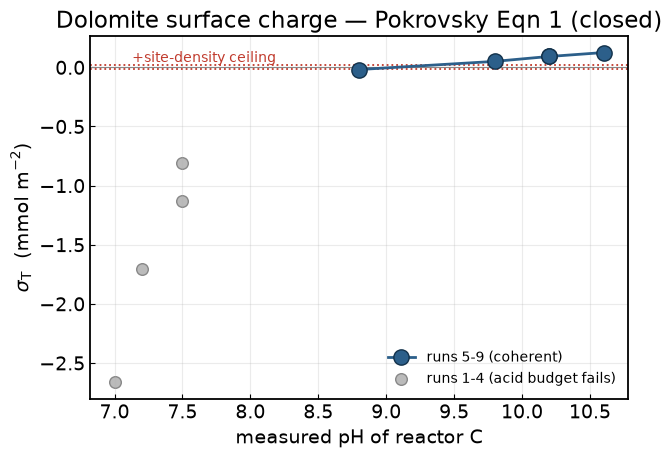

In [9]:
import matplotlib as mpl
_rc = {'font.size':14,'axes.linewidth':1.3,'xtick.direction':'in','ytick.direction':'in'}
with mpl.rc_context(_rc):
    fig, ax = plt.subplots(figsize=(6.6,4.8))
    ax.axhline(0, color='#888', ls='-', lw=0.8)
    for y in (SITE_CEILING, -SITE_CEILING):
        ax.axhline(y, color='#c0392b', ls=':', lw=1.3)
    ax.text(min(C['pH'])+0.1, SITE_CEILING, ' +site-density ceiling', color='#c0392b',
            va='bottom', fontsize=10)

    coh  = surf[surf.index >= 5].join(C.set_index('run')['pH'].rename('pHm'))
    drop = surf[surf.index <= 4].join(C.set_index('run')['pH'].rename('pHm'))
    ax.plot(coh['pHm'], coh['sigma_T (mmol/m2)'], '-o', color='#2c5f8a', mec='#12314a',
            ms=11, lw=2, label='runs 5-9 (coherent)')
    ax.scatter(drop['pHm'], drop['sigma_T (mmol/m2)'], color='#bbb', ec='#888', s=70,
               zorder=1, label='runs 1-4 (acid budget fails)')

    ax.set_xlabel('measured pH of reactor C')
    ax.set_ylabel(r'$\sigma_\mathrm{T}$  (mmol m$^{-2}$)')
    ax.set_title(f'Dolomite surface charge — Pokrovsky Eqn 1 ({CARBONATE})')
    ax.legend(frameon=False, fontsize=10)
    ax.grid(alpha=0.25)
    plt.tight_layout(); plt.savefig('surface_charge_vs_pH.png', dpi=150); plt.show()

## Notes

1. **Pokrovsky Eqn 1, measured pH.** The surface charge is the charge-sum difference between the
   conservative A+B mix and reactor C, both speciated at the **measured** pH — the paper's method. No
   surface complexation model is fitted.
2. **Carbonate switch.** `CARBONATE='closed'` uses the measured alkalinity (Pokrovsky) and keeps
   carbonate near the measured ~1–2 mM. `'open'` fixes pCO₂; at atmospheric pCO₂ it predicts hundreds
   of mM of carbonate above pH 9 and the base-run surface charge blows up to ±10–25 mmol/m². That is
   why closed is the default; set `CARBONATE='open'` to reproduce the breakdown.
3. **Runs 1–4 excluded.** The acid budget fails by 20–40× (far more cation dissolved than the acid can
   explain) and the released carbon is not accounted for, so those runs are not titrations. The curve
   is built from runs 5–9.
4. **Activity coefficients (Davies)** and Plummer–Busenberg / Nordstrom formation constants, as in the
   paper. Ionic strength is iterated to convergence inside `speciate`.
5. **Site-density ceiling** 0.0166 mmol/m² ≈ 10 sites/nm²; the coherent points are compared against it
   in the figure.